In [20]:
# =============================================================================
# PROJECT 4: TITANIC SURVIVAL CLASSIFICATION
# =============================================================================
# GOAL: Predict whether a passenger survived the Titanic disaster (0 = No, 1 = Yes)
# This is a BINARY CLASSIFICATION problem — the output is one of two classes.
#
# DATASET COLUMNS:
#   PassengerId – Unique ID (not useful for prediction)
#   Survived    – TARGET variable (what we want to predict)
#   Pclass      – Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
#   Name        – Passenger name
#   Sex         – Gender
#   Age         – Age in years
#   SibSp       – # of siblings / spouses aboard
#   Parch       – # of parents / children aboard
#   Ticket      – Ticket number
#   Fare        – Passenger fare
#   Cabin       – Cabin number
#   Embarked    – Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)
# =============================================================================

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn: the main machine learning library in Python
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Classifiers we will compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

# Make plots look clean
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: LOAD & EXPLORE THE DATA (EDA)
# Exploratory Data Analysis = understanding what's in the data before modeling
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv("titanic_train.csv")

print("=" * 60)
print("STEP 1: BASIC DATA EXPLORATION")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")   # rows × columns
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types & Non-Null Counts:")
print(df.info())

print("\nSummary Statistics (numeric columns):")
print(df.describe())

# Check for missing values — crucial before building models
print("\nMissing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

# KEY OBSERVATIONS:
# - Age: 177 missing (19.8%) → impute with median
# - Cabin: 687 missing (77%)  → too many missing, drop or create a binary flag
# - Embarked: 2 missing       → impute with mode (most common value)

STEP 1: BASIC DATA EXPLORATION

Dataset Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000 

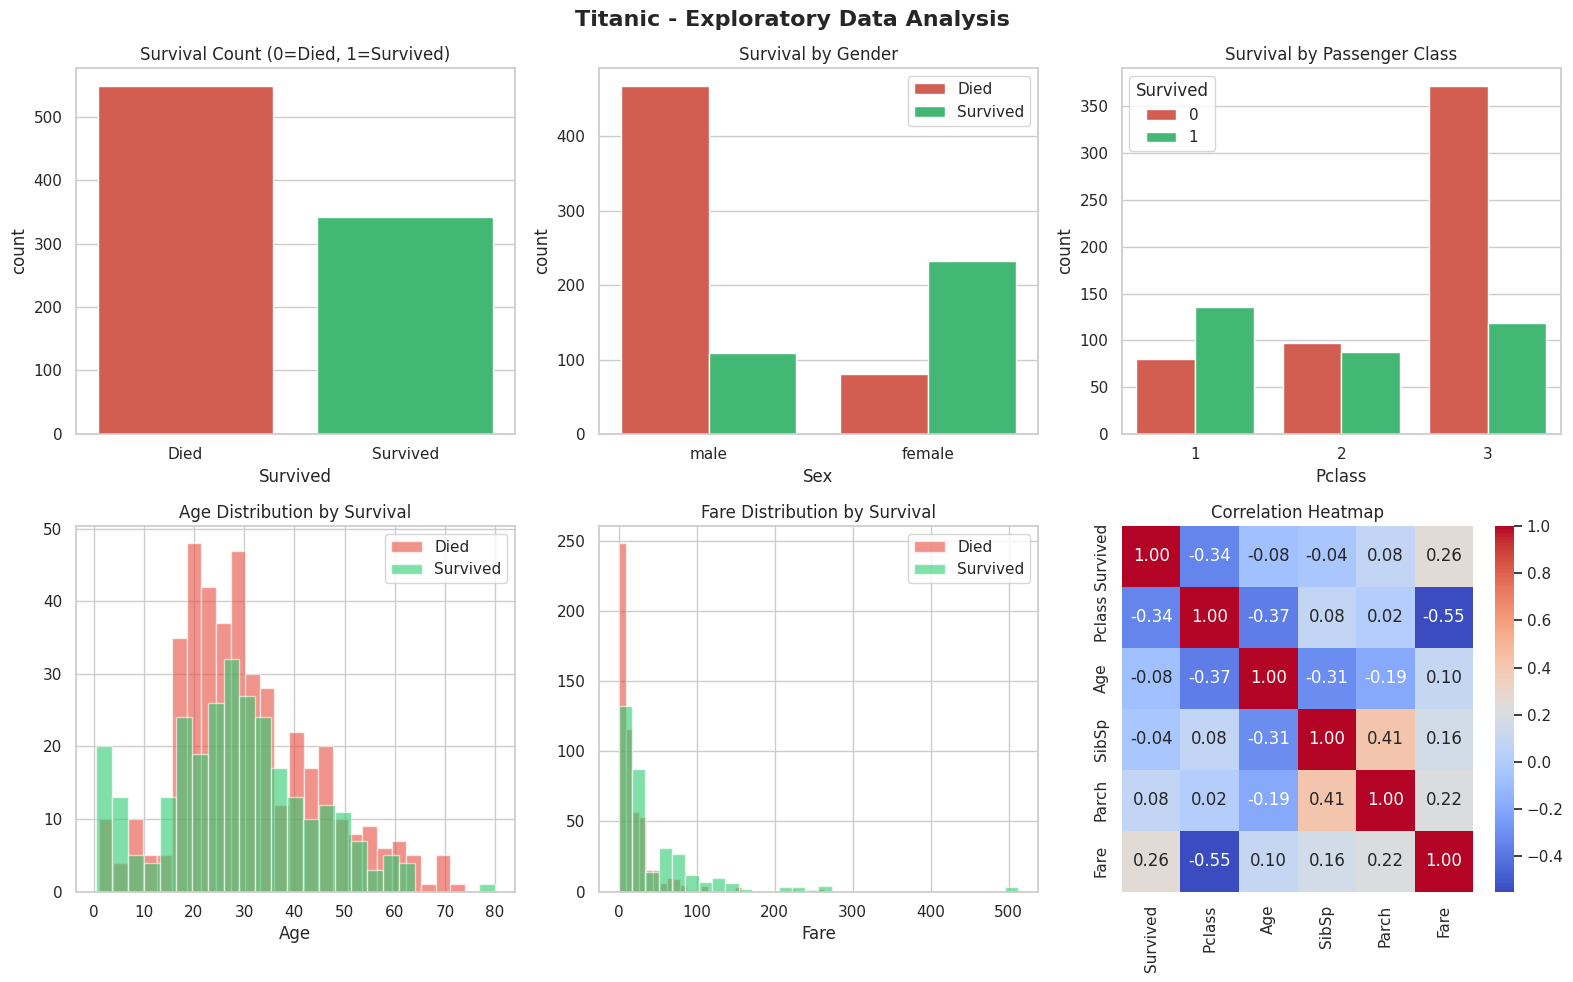

EDA plots saved as 'eda_plots.png'


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: DATA VISUALIZATION
# Visualizations help us understand which features matter for survival
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Titanic - Exploratory Data Analysis", fontsize=16, fontweight='bold')

# 3.1 Overall survival count
sns.countplot(x='Survived', data=df, ax=axes[0, 0], palette=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title("Survival Count (0=Died, 1=Survived)")
axes[0, 0].set_xticklabels(['Died', 'Survived'])

# 3.2 Survival by gender
# Hypothesis: Women had higher survival rate ("women and children first")
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0, 1], palette=['#e74c3c', '#2ecc71'])
axes[0, 1].set_title("Survival by Gender")
axes[0, 1].legend(['Died', 'Survived'])

# 3.3 Survival by Passenger Class
# Hypothesis: 1st class passengers had more access to lifeboats
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0, 2], palette=['#e74c3c', '#2ecc71'])
axes[0, 2].set_title("Survival by Passenger Class")

# 3.4 Age distribution by survival
# Histogram with kernel density estimate (KDE)
df[df['Survived'] == 0]['Age'].dropna().hist(ax=axes[1, 0], alpha=0.6, color='#e74c3c', label='Died', bins=25)
df[df['Survived'] == 1]['Age'].dropna().hist(ax=axes[1, 0], alpha=0.6, color='#2ecc71', label='Survived', bins=25)
axes[1, 0].set_title("Age Distribution by Survival")
axes[1, 0].legend()
axes[1, 0].set_xlabel("Age")

# 3.5 Fare distribution by survival
df[df['Survived'] == 0]['Fare'].hist(ax=axes[1, 1], alpha=0.6, color='#e74c3c', label='Died', bins=30)
df[df['Survived'] == 1]['Fare'].hist(ax=axes[1, 1], alpha=0.6, color='#2ecc71', label='Survived', bins=30)
axes[1, 1].set_title("Fare Distribution by Survival")
axes[1, 1].legend()
axes[1, 1].set_xlabel("Fare")

# 3.6 Correlation Heatmap — shows linear relationships between numeric features
# Values close to +1 or -1 mean strong relationship
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(numeric_df, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 2])
axes[1, 2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_plots.png", bbox_inches='tight')
plt.show()
print("EDA plots saved as 'eda_plots.png'")

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: FEATURE ENGINEERING
# Creating new or better features from existing columns
# Good features are CRITICAL — "garbage in, garbage out"
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 2: FEATURE ENGINEERING")
print("=" * 60)

# 4.1 Extract Title from Name
# The title (Mr, Mrs, Miss, Master) carries information about age, gender, and social status
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()
print("\nUnique Titles found:", df['Title'].unique())

# Group rare titles into a single 'Rare' category
rare_titles = ['Don', 'Rev', 'Dr', 'Major', 'Lady', 'Sir', 'Col', 'Capt',
               'the Countess', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
print("Simplified Titles:", df['Title'].value_counts().to_dict())

# 4.2 Family Size
# SibSp = siblings/spouses, Parch = parents/children
# FamilySize captures total family members on board
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

# Categorize: solo travellers often had different survival odds than families
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print(f"\nAlone passengers: {df['IsAlone'].sum()} / {len(df)}")

# 4.3 Has Cabin flag
# Cabin is 77% missing — rather than drop it, we create a binary: had cabin info or not
# Having a cabin number correlates with being 1st class
df['HasCabin'] = df['Cabin'].notna().astype(int)


STEP 2: FEATURE ENGINEERING

Unique Titles found: ['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']
Simplified Titles: {'Mr': 517, 'Miss': 185, 'Mrs': 126, 'Master': 40, 'Rare': 23}

Alone passengers: 537 / 891


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: DATA PREPROCESSING
# Cleaning and transforming data so ML algorithms can work with it
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 3: DATA PREPROCESSING")
print("=" * 60)

# 5.1 Handle Missing Values
# IMPUTATION: filling missing values with a sensible substitute

# Age: fill with MEDIAN (robust to outliers, unlike mean)
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"Imputed Age missing values with median: {median_age:.1f}")

# Embarked: fill with MODE (most frequent value)
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"Imputed Embarked missing values with mode: '{mode_embarked}'")

# 5.2 Encode Categorical Variables
# ML models understand numbers, not text.
# LABEL ENCODING: maps each category to a unique integer
le = LabelEncoder()

df['Sex_encoded'] = le.fit_transform(df['Sex'])            # female=0, male=1
df['Embarked_encoded'] = le.fit_transform(df['Embarked'])  # C=0, Q=1, S=2
df['Title_encoded'] = le.fit_transform(df['Title'])        # each title gets a number

print("\nEncoding complete:")
print("  Sex: female=0, male=1")
print("  Embarked: C/Q/S → 0/1/2")

# 5.3 Select Final Features for the Model
# We drop: PassengerId (just an ID), Name (extracted Title from it),
#          Ticket (too noisy), Cabin (replaced by HasCabin), raw text columns
FEATURES = ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare',
            'Embarked_encoded', 'Title_encoded', 'FamilySize', 'IsAlone', 'HasCabin']

TARGET = 'Survived'

X = df[FEATURES].copy()
y = df[TARGET]

# Final safety check: ensure no NaN values remain
assert X.isnull().sum().sum() == 0, "Still have NaN values — check imputation steps!"

print(f"\nFeatures used: {FEATURES}")
print(f"Target: {TARGET}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Check class balance — important for classification!
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"Survival rate: {y.mean():.2%}")


STEP 3: DATA PREPROCESSING
Imputed Age missing values with median: 28.0
Imputed Embarked missing values with mode: 'S'

Encoding complete:
  Sex: female=0, male=1
  Embarked: C/Q/S → 0/1/2

Features used: ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_encoded', 'Title_encoded', 'FamilySize', 'IsAlone', 'HasCabin']
Target: Survived
X shape: (891, 11), y shape: (891,)

Class distribution:
Survived
0    549
1    342
Name: count, dtype: int64
Survival rate: 38.38%


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: TRAIN-TEST SPLIT
# We NEVER train and evaluate on the same data — that leads to overfitting.
# The model would just "memorize" the training data.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 4: TRAIN-TEST SPLIT")
print("=" * 60)

# 80% for training, 20% for testing
# stratify=y: ensures both splits have the same survival ratio
# random_state=42: makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

# 5.4 Feature Scaling
# Some algorithms (like SVM, KNN, Logistic Regression) are sensitive to scale.
# StandardScaler: transforms each feature to have mean=0, std=1
# IMPORTANT: fit scaler ONLY on training data, then apply to test data
# (to prevent "data leakage" — test data influencing the training process)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


STEP 4: TRAIN-TEST SPLIT
Training set: 712 samples
Test set:     179 samples


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: TRAIN MULTIPLE MODELS
# We try several algorithms and compare their performance
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 5: TRAIN & EVALUATE MULTIPLE CLASSIFIERS")
print("=" * 60)

# Define models to compare
# Each algorithm learns patterns differently:
models = {
    # LOGISTIC REGRESSION: learns a linear decision boundary
    # Outputs a probability between 0 and 1
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),

    # DECISION TREE: builds a flowchart of if-else rules
    # Highly interpretable but prone to overfitting
    'Decision Tree': DecisionTreeClassifier(random_state=42),

    # RANDOM FOREST: many decision trees voting together (ensemble)
    # More robust, less overfitting than a single tree
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),

    # GRADIENT BOOSTING: trees built sequentially, each fixing previous errors
    # Very powerful but slower to train
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),

    # SVM (Support Vector Machine): finds the best hyperplane to separate classes
    # Works well in high-dimensional spaces
    'SVM': SVC(probability=True, random_state=42),

    # KNN (K-Nearest Neighbors): classifies based on the k closest training points
    # Simple, non-parametric — no explicit training phase
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, model in models.items():
    # Use scaled data for scale-sensitive models
    if name in ['Logistic Regression', 'SVM', 'KNN']:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    # CROSS-VALIDATION: split training data into 5 folds
    # Train on 4 folds, validate on 1 fold, repeat 5 times
    # This gives a more reliable performance estimate than a single split
    cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy')

    # Train on the full training set
    model.fit(X_tr, y_train)

    # Predict on the test set
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]  # probability of class 1 (survived)

    # Compute metrics
    test_acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'scaled': name in ['Logistic Regression', 'SVM', 'KNN']
    }

    print(f"\n{'─'*50}")
    print(f"  Model: {name}")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  ROC-AUC Score: {roc_auc:.4f}")
    # ROC-AUC = Area Under the Curve; 1.0 = perfect, 0.5 = random guessing


STEP 5: TRAIN & EVALUATE MULTIPLE CLASSIFIERS

──────────────────────────────────────────────────
  Model: Logistic Regression
  CV Accuracy: 0.7964 ± 0.0225
  Test Accuracy: 0.8156
  ROC-AUC Score: 0.8581

──────────────────────────────────────────────────
  Model: Decision Tree
  CV Accuracy: 0.7543 ± 0.0412
  Test Accuracy: 0.7654
  ROC-AUC Score: 0.7468

──────────────────────────────────────────────────
  Model: Random Forest
  CV Accuracy: 0.8007 ± 0.0388
  Test Accuracy: 0.8101
  ROC-AUC Score: 0.8375

──────────────────────────────────────────────────
  Model: Gradient Boosting
  CV Accuracy: 0.8189 ± 0.0364
  Test Accuracy: 0.7989
  ROC-AUC Score: 0.8231

──────────────────────────────────────────────────
  Model: SVM
  CV Accuracy: 0.8245 ± 0.0197
  Test Accuracy: 0.8324
  ROC-AUC Score: 0.8580

──────────────────────────────────────────────────
  Model: KNN
  CV Accuracy: 0.7978 ± 0.0241
  Test Accuracy: 0.8045
  ROC-AUC Score: 0.8337


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: DETAILED EVALUATION OF BEST MODEL
# ─────────────────────────────────────────────────────────────────────────────

# Find the best model by test accuracy
best_name = max(results, key=lambda k: results[k]['test_acc'])
best = results[best_name]
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_name} (Test Accuracy: {best['test_acc']:.4f})")
print(f"{'='*60}")

# Classification Report
# Precision: of all predicted survivors, how many actually survived?
# Recall: of all actual survivors, how many did we correctly identify?
# F1 Score: harmonic mean of precision and recall (balance between both)
print("\nDetailed Classification Report:")
print(classification_report(y_test, best['y_pred'], target_names=['Died', 'Survived']))


BEST MODEL: SVM (Test Accuracy: 0.8324)

Detailed Classification Report:
              precision    recall  f1-score   support

        Died       0.86      0.87      0.86       110
    Survived       0.79      0.77      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



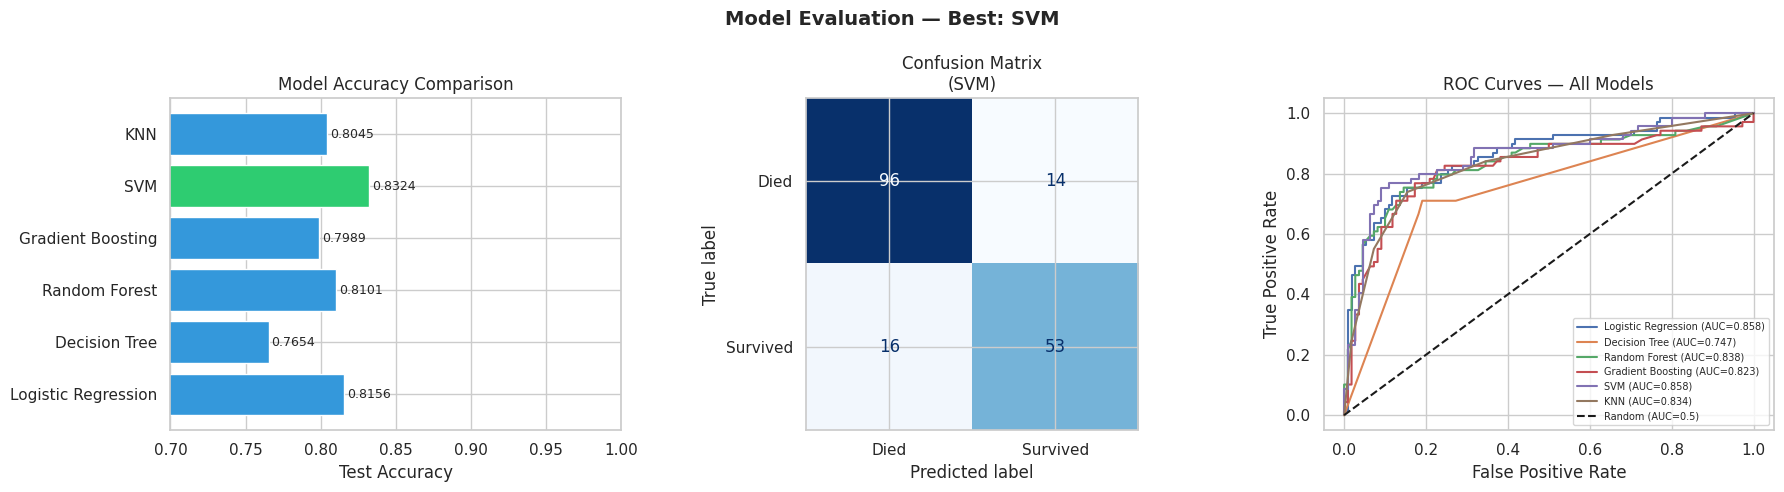

Model evaluation plots saved as 'model_evaluation.png'


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: VISUALIZE MODEL RESULTS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Model Evaluation — Best: {best_name}", fontsize=14, fontweight='bold')

# 9.1 Model Comparison Bar Chart
model_names = list(results.keys())
test_accs = [results[m]['test_acc'] for m in model_names]
colors = ['#2ecc71' if m == best_name else '#3498db' for m in model_names]

bars = axes[0].barh(model_names, test_accs, color=colors)
axes[0].set_xlabel("Test Accuracy")
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_xlim(0.7, 1.0)
for bar, acc in zip(bars, test_accs):
    axes[0].text(acc + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{acc:.4f}', va='center', fontsize=9)

# 9.2 Confusion Matrix
# Shows: True Positives, True Negatives, False Positives, False Negatives
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f"Confusion Matrix\n({best_name})")

# 9.3 ROC Curve
# Plots True Positive Rate vs False Positive Rate at different thresholds
# Closer to the top-left corner = better model
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[2].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")

axes[2].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curves — All Models")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig("model_evaluation.png", bbox_inches='tight')
plt.show()
print("Model evaluation plots saved as 'model_evaluation.png'")


STEP 6: FEATURE IMPORTANCE (Random Forest)

Feature Importances:
  Fare                : 0.2349  ███████████████████████
  Age                 : 0.2026  ████████████████████
  Sex_encoded         : 0.1788  █████████████████
  Title_encoded       : 0.1194  ███████████
  Pclass              : 0.0622  ██████
  HasCabin            : 0.0603  ██████
  FamilySize          : 0.0484  ████
  SibSp               : 0.0318  ███
  Embarked_encoded    : 0.0303  ███
  Parch               : 0.0191  █
  IsAlone             : 0.0122  █


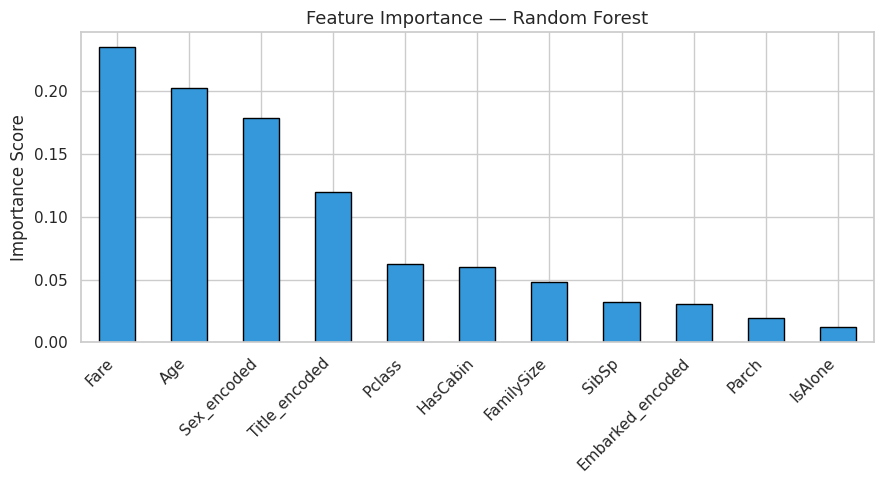

Feature importance plot saved as 'feature_importance.png'


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: FEATURE IMPORTANCE
# Which features influenced the model's decisions the most?
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 6: FEATURE IMPORTANCE (Random Forest)")
print("=" * 60)

# Random Forest provides feature importance natively
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

print("\nFeature Importances:")
for feat, imp in importances.items():
    bar = '█' * int(imp * 100)
    print(f"  {feat:20s}: {imp:.4f}  {bar}")

plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title("Feature Importance — Random Forest", fontsize=13)
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches='tight')
plt.show()
print("Feature importance plot saved as 'feature_importance.png'")

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: HYPERPARAMETER TUNING (Random Forest)
# Hyperparameters are model settings set BEFORE training.
# GridSearchCV tries all combinations and picks the best one using cross-validation.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 7: HYPERPARAMETER TUNING (GridSearchCV on Random Forest)")
print("=" * 60)

param_grid = {
    'n_estimators': [100, 200],        # number of trees
    'max_depth': [None, 5, 10],        # max tree depth (None = unlimited)
    'min_samples_split': [2, 5],       # min samples needed to split a node
    'min_samples_leaf': [1, 2]         # min samples required at a leaf node
}

print("\nSearching best hyperparameters... (this may take ~30 seconds)")
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,                  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,             # use all CPU cores
    verbose=0
)
rf_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best CV Score:   {rf_grid.best_score_:.4f}")

# Evaluate tuned model on test set
tuned_pred = rf_grid.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_pred)
print(f"Tuned Model Test Accuracy: {tuned_acc:.4f}")
print(f"Improvement over baseline RF: {tuned_acc - results['Random Forest']['test_acc']:+.4f}")


STEP 7: HYPERPARAMETER TUNING (GridSearchCV on Random Forest)

Searching best hyperparameters... (this may take ~30 seconds)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score:   0.8259
Tuned Model Test Accuracy: 0.7933
Improvement over baseline RF: -0.0168


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\n{'Model':<25} {'CV Acc':>9} {'Test Acc':>10} {'ROC-AUC':>9}")
print("─" * 57)
for name in sorted(results, key=lambda k: results[k]['test_acc'], reverse=True):
    r = results[name]
    marker = " ← BEST" if name == best_name else ""
    print(f"{name:<25} {r['cv_mean']:>8.4f}  {r['test_acc']:>9.4f}  {r['roc_auc']:>8.4f}{marker}")
print(f"\n{'Tuned Random Forest':<25} {'':>9} {tuned_acc:>10.4f}")

print("""
KEY TAKEAWAYS:
─────────────────────────────────────────────────────
1. PREPROCESSING matters: Handling missing values,
   encoding categoricals, and scaling are essential.

2. FEATURE ENGINEERING boosts performance:
   Title, FamilySize, IsAlone, HasCabin all help.

3. ENSEMBLE methods (Random Forest, Gradient Boosting)
   generally outperform single models.

4. CROSS-VALIDATION gives more reliable estimates
   than a single train/test split.

5. HYPERPARAMETER TUNING can squeeze extra performance,
   but returns diminish quickly.

6. Always check FEATURE IMPORTANCE to understand
   what the model is actually learning.
─────────────────────────────────────────────────────
""")


FINAL SUMMARY

Model                        CV Acc   Test Acc   ROC-AUC
─────────────────────────────────────────────────────────
SVM                         0.8245     0.8324    0.8580 ← BEST
Logistic Regression         0.7964     0.8156    0.8581
Random Forest               0.8007     0.8101    0.8375
KNN                         0.7978     0.8045    0.8337
Gradient Boosting           0.8189     0.7989    0.8231
Decision Tree               0.7543     0.7654    0.7468

Tuned Random Forest                     0.7933

KEY TAKEAWAYS:
─────────────────────────────────────────────────────
1. PREPROCESSING matters: Handling missing values,
   encoding categoricals, and scaling are essential.

2. FEATURE ENGINEERING boosts performance:
   Title, FamilySize, IsAlone, HasCabin all help.

3. ENSEMBLE methods (Random Forest, Gradient Boosting)
   generally outperform single models.

4. CROSS-VALIDATION gives more reliable estimates
   than a single train/test split.

5. HYPERPARAMETER TUNING can